# Arbitration: Toward a Deterministic Model

A follow-on to `1_war_value_exploration.ipynb`, which found that a simple linear formula
(`AAV ~ WAR + service_time`, split by role) explains real, substantial variance in arbitration pay
(R² up to ~0.75 in-sample). This notebook picks that formula up and pushes it toward something
trustworthy enough to actually use: cleaning real data-quality bugs out of the training set, fixing a
role-classification bug that was silently corrupting the pitcher split, diagnosing *why* the model's
biggest misses happen, and fixing what's fixable.

**Headline result:** a `log(AAV) ~ WAR × service_time interaction + volume + service_time` formula,
fit separately for batters/starters/relievers on a cleaned, correctly-classified dataset, is reliable
for Super Two and Arb-1 (~79-95% of predictions within ±$1M) but degrades sharply by Arb-3
(as low as 40% within ±$1M for batters) — arbitration's walk-year dynamics need more than a formula
can give them. The breakdown at the end tells you exactly where to trust this model and where not to.

**This is exploratory analysis, not part of the production pipeline** (`data_generation/`, `agent/`) —
standalone research, same as notebook 1.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

DATASET_DIR = "../dataset"


## 1. Load data and reproduce the role-split formula from notebook 1

Same setup as before: filter to `contract_type == "arb"`, derive `war_3y`/`volume_3y` from the
position-appropriate stat family (batting vs. pitching), and fit `AAV ~ war_3y + volume_3y +
service_time` separately for batters/SP/RP.


In [2]:
df = pd.read_csv(f"{DATASET_DIR}/contracts_with_stats.csv")
players = pd.read_csv(f"{DATASET_DIR}/players.csv").drop_duplicates(subset="player_id")

pos = df["position"]
is_pitcher = pos.str.contains("SP|RP", regex=True) | (pos == "P")
label_is_sp = pos.str.contains("SP", regex=True)
label_is_rp = pos.str.contains("RP", regex=True) & ~label_is_sp
df["role_by_label"] = np.select(
    [~is_pitcher, label_is_sp, label_is_rp, is_pitcher], ["batter", "SP", "RP", "P(other)"], default="batter"
)

df["aav"] = df["value"] / df["duration"]
df["log_aav"] = np.log(df["aav"])
df["war_3y"] = np.where(is_pitcher, df["pit_war_3y"], df["bat_war_3y"])
df["volume_3y"] = np.where(is_pitcher, df["pit_innings_pitched_3y"], df["bat_plate_appearances_3y"])
df["war_x_service"] = df["war_3y"] * df["service_time"]

print(f"total rows: {len(df)}, arb rows (raw, unfiltered): {(df['contract_type']=='arb').sum()}")


total rows: 14900, arb rows (raw, unfiltered): 2995


/Users/robbiefishel/Documents/projects/MLBContracts/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 2. Clean two real data-quality issues out of the arb working set

**Issue 1 — multi-year extensions mislabeled as "arb".** `contract_type == "arb"` should mean a
one-year, arbitration-determined salary, but some rows have `duration > 1` — these are long-term
extensions signed while a player was arb-eligible (Stanton 13yr/$325M, Kershaw 7yr/$215M, Trout
6yr/$144.5M...). Their economics (buying out free-agent years, term security) aren't what this model is
trying to capture.

**Issue 2 — broken stats-join rows.** Some rows have `games > 0` but `plate_appearances == 0` (or
`innings_pitched == 0` for pitchers) for the same window — impossible for a real season, a sign of a
broken join (confirmed root cause: a player-ID/FanGraphs-ID collision between two same-named real
players — see the data-quality investigation for detail; not re-derived here).


In [3]:
arb_raw = df[df["contract_type"] == "arb"].copy()
is_p_raw = is_pitcher.loc[arb_raw.index]

multi_year = arb_raw["duration"] > 1
broken_stats = (
    ((~is_p_raw) & (arb_raw["bat_games_3y"] > 0) & (arb_raw["bat_plate_appearances_3y"] == 0))
    | ((is_p_raw) & (arb_raw["pit_games_3y"] > 0) & (arb_raw["pit_innings_pitched_3y"] == 0))
)
is_ohtani = arb_raw["player_id"] == "Ohtani_24661"

print(f"raw arb rows: {len(arb_raw)}")
print(f"  multi-year extensions (duration>1): {multi_year.sum()}")
print(f"  broken stats-join rows: {broken_stats.sum()}")
print(f"  Shohei Ohtani rows (excluded separately, see Section 6): {is_ohtani.sum()}")

arb = arb_raw[~multi_year & ~broken_stats & ~is_ohtani].copy()
print(f"cleaned arb rows: {len(arb)}")


raw arb rows: 2995
  multi-year extensions (duration>1): 212
  broken stats-join rows: 5
  Shohei Ohtani rows (excluded separately, see Section 6): 2
cleaned arb rows: 2778


## 3. A bigger, previously-invisible bug: `position` doesn't reliably distinguish SP from RP

Splitting pitchers into starters and relievers (done in notebook 1 to let each role have its own
WAR-to-dollar slope) relied on the scraped `position` field. That field turns out to be unreliable:
**Corbin Burnes** — a full-time ace, 2023 NL Cy Young winner — is labeled `position="RP"` for
every one of his contract rows, despite 400-600+ innings pitched and 70-97 games *started* per 3-year
window. Checking the whole dataset for the same signature (`position=="RP"` with a starter-scale
workload) finds this is not a one-off.


In [4]:
mislabeled = df[(df["position"] == "RP") & (df["pit_innings_pitched_3y"] > 300)]
print(f"dataset-wide rows labeled RP with starter-scale workload (>300 IP over 3y): {len(mislabeled)}")
print(f"unique players affected: {mislabeled['player_id'].nunique()}")
print()
arb_mislabeled = mislabeled[mislabeled["player_id"].isin(arb_raw["player_id"])]
print(f"of those, rows that fall within the arb dataset specifically: "
      f"{arb_raw[(arb_raw['position']=='RP') & (arb_raw['pit_innings_pitched_3y']>300)].shape[0]}")
print()
print("a few examples:")
print(mislabeled[["player_id", "position", "pit_innings_pitched_3y", "pit_games_started_3y"]]
      .drop_duplicates(subset="player_id").head(8).to_string(index=False))


dataset-wide rows labeled RP with starter-scale workload (>300 IP over 3y): 124
unique players affected: 58

of those, rows that fall within the arb dataset specifically: 66

a few examples:
      player_id position  pit_innings_pitched_3y  pit_games_started_3y
   Liriano_5289       RP                   404.1                  69.0
Chamberlain_577       RP                   329.1                  43.0
  Rodriguez_384       RP                   538.0                  90.0
     Hammel_832       RP                   432.2                  65.0
  Duensing_7438       RP                   376.1                  50.0
    Hunter_7558       RP                   324.2                  52.0
     Cecil_5403       RP                   389.2                  65.0
     Lannan_926       RP                   534.1                  91.0


**Fix: classify role from actual workload, not the scraped label.** `games_started_3y / games_3y` is
strongly bimodal in this dataset (a big spike near 0.0 for true relievers, a big spike near 1.0 for true
starters) — a plain majority-starts threshold (≥0.5 → SP) cleanly separates the two groups and
doesn't depend on trusting an upstream label at all.


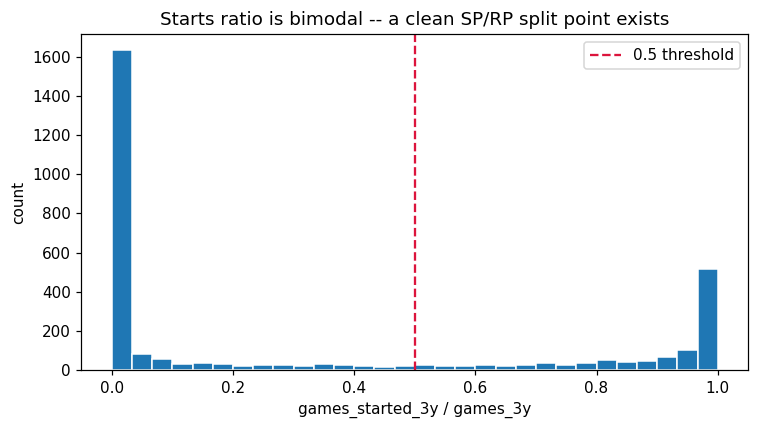

In [5]:
gs_ratio = df["pit_games_started_3y"] / df["pit_games_3y"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gs_ratio.dropna(), bins=30, edgecolor="white")
ax.axvline(0.5, color="crimson", linestyle="--", label="0.5 threshold")
ax.set_xlabel("games_started_3y / games_3y")
ax.set_ylabel("count")
ax.set_title("Starts ratio is bimodal -- a clean SP/RP split point exists")
ax.legend()
fig.tight_layout()


In [6]:
workload_sp = gs_ratio >= 0.5
workload_rp = gs_ratio < 0.5
has_workload = gs_ratio.notna()

role = np.select(
    [
        ~is_pitcher,
        is_pitcher & has_workload & workload_sp,
        is_pitcher & has_workload & workload_rp,
        is_pitcher & ~has_workload & label_is_sp,
        is_pitcher & ~has_workload & label_is_rp,
    ],
    ["batter", "SP", "RP", "SP", "RP"],
    default="P(other)",
)
df["role"] = role

moved = (df["role_by_label"] != df["role"]) & is_pitcher
print(f"pitcher rows reclassified vs. the old label-based split: {moved.sum()}")
print(pd.crosstab(
    pd.Series(df.loc[is_pitcher, "role_by_label"], name="old label"),
    pd.Series(df.loc[is_pitcher, "role"], name="workload-based"),
))


pitcher rows reclassified vs. the old label-based split: 616
workload-based  P(other)    RP    SP
old label                           
P(other)             579   168    39
RP                     0  4420   186
SP                     0   223  2722


In [7]:
# re-derive the cleaned arb working set now that `role` reflects workload, not the label
arb = df[(df["contract_type"] == "arb")].copy()
is_p_arb = is_pitcher.loc[arb.index]
multi_year = arb["duration"] > 1
broken_stats = (
    ((~is_p_arb) & (arb["bat_games_3y"] > 0) & (arb["bat_plate_appearances_3y"] == 0))
    | ((is_p_arb) & (arb["pit_games_3y"] > 0) & (arb["pit_innings_pitched_3y"] == 0))
)
is_ohtani = arb["player_id"] == "Ohtani_24661"
arb = arb[~multi_year & ~broken_stats & ~is_ohtani].copy()
print(f"final cleaned + reclassified arb working set: {len(arb)} rows")
print(arb["role"].value_counts())


final cleaned + reclassified arb working set: 2778 rows
role
batter      1184
RP          1012
SP           569
P(other)      13
Name: count, dtype: int64


## 4. Honest evaluation methodology: walk-forward, not a random split

Every benchmark below is a **walk-forward** evaluation: for each year Y from 2017 to 2026, fit on all
cleaned arb rows strictly *before* Y, predict year Y, and pool the results. This mirrors how the model
would actually be used (predicting a future year from past data) and avoids the optimism of a random
train/test split, which would let information from the target year leak into training.


In [8]:
def raw_ols_fit(data, y_col, x_cols):
    sub = data[[y_col] + x_cols].dropna()
    n = len(sub)
    X = np.column_stack([sub[c].values for c in x_cols] + [np.ones(n)])
    y = sub[y_col].values
    coefs, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coefs


def walk_forward(data, specs, target_col, start_year=2017, end_year=2027, log_target=False):
    """specs: {role: [feature columns]}. Returns pooled OOS predictions with metadata."""
    records = []
    for test_year in range(start_year, end_year):
        train = data[data["contract_year"] < test_year]
        test = data[data["contract_year"] == test_year]
        for role, xcols in specs.items():
            tr = train[train["role"] == role]
            te = test[test["role"] == role]
            sub_tr = tr[[target_col] + xcols].dropna()
            if len(sub_tr) < 20:
                continue
            coefs = raw_ols_fit(tr, target_col, xcols)
            cols = list(dict.fromkeys(["player_id", "contract_id", "aav"] + xcols))
            sub_te = te[cols].dropna(subset=xcols + ["aav"]).copy()
            if len(sub_te) == 0:
                continue
            X = np.column_stack([sub_te[c].values for c in xcols] + [np.ones(len(sub_te))])
            pred = X @ coefs
            if log_target:
                pred = np.exp(pred)
            sub_te["role"] = role
            sub_te["contract_year"] = test_year
            sub_te["predicted"] = pred
            sub_te["resid"] = sub_te["aav"] - sub_te["predicted"]
            records.append(sub_te)
    out = pd.concat(records, ignore_index=True)
    return out.merge(players[["player_id", "first_name", "last_name"]], on="player_id", how="left").assign(
        name=lambda d: (d["first_name"].fillna("") + " " + d["last_name"].fillna("")).str.strip()
    )


def summarize(res, label):
    g = res.groupby("role")["resid"].apply(lambda x: x.abs().mean()).round(3)
    print(f"{label}: MAE by role -> {g.to_dict()}   |   pooled MAE={res['resid'].abs().mean():.3f}")


## 5. Baseline: additive formula (WAR + volume + service_time)


In [9]:
specs_base = {
    "batter": ["war_3y", "volume_3y", "service_time"],
    "SP": ["war_3y", "service_time"],
    "RP": ["war_3y", "volume_3y", "service_time"],
}
res_base = walk_forward(arb, specs_base, "aav")
summarize(res_base, "Base (additive)")


Base (additive): MAE by role -> {'RP': 0.871, 'SP': 1.178, 'batter': 1.495}   |   pooled MAE=1.223


## 6. Outlier diagnosis: why does the model miss, and by how much?

Looking at the biggest absolute misses reveals a clear, non-random pattern.


In [10]:
top40 = res_base.reindex(res_base["resid"].abs().sort_values(ascending=False).index).head(40)
print("Sign of the 40 largest misses:")
print(f"  underpredicted (actual > predicted): {(top40['resid']>0).sum()}")
print(f"  overpredicted (actual < predicted):  {(top40['resid']<0).sum()}")
print()
print("Top 10 by absolute miss:")
print(top40.head(10)[["name", "role", "contract_year", "aav", "predicted", "resid"]].round(2).to_string(index=False))


Sign of the 40 largest misses:
  underpredicted (actual > predicted): 40
  overpredicted (actual < predicted):  0

Top 10 by absolute miss:
                 name   role  contract_year  aav  predicted  resid
         Tarik Skubal     SP           2026 32.0      13.76  18.24
Vladimir Guerrero Jr. batter           2025 28.5      10.45  18.05
            Juan Soto batter           2024 31.0      13.27  17.73
         Mookie Betts batter           2020 27.0      12.43  14.57
            Juan Soto batter           2023 23.0       9.26  13.74
       Josh Donaldson batter           2018 23.0       9.70  13.30
          Kris Bryant batter           2021 19.5       6.75  12.75
     Francisco Lindor batter           2021 22.3      10.96  11.34
      George Springer batter           2020 21.0       9.79  11.21
       Cody Bellinger batter           2022 17.0       6.33  10.67


**All 40 of the largest misses are underpredictions** — a symmetric, "final-offer arbitration is a
coin flip" story would predict roughly equal numbers of large misses in both directions. It doesn't
look like that. The biggest misses are elite players in their **final arb year**
(`service_time` ≈ 5.0-5.2, one year from free agency): Ohtani, Skubal, Guerrero Jr., Soto, Betts,
Judge — all clustered right at the edge of the service-time range.

The *biggest overpredictions*, by contrast, are high-WAR players with `service_time == 3.00` exactly
— first-year arb (arb-1):


In [11]:
print("Biggest overpredictions:")
print(res_base.sort_values("resid").head(6)[["name", "role", "contract_year", "aav", "predicted", "resid", "service_time"]]
      .round(2).to_string(index=False))


Biggest overpredictions:
           name   role  contract_year  aav  predicted  resid  service_time
    Steven Kwan batter           2025 4.18       8.26  -4.08          3.00
   Michael King     RP           2025 4.00       7.92  -3.92          5.00
Adley Rutschman batter           2025 5.50       9.00  -3.50          3.00
     Chad Green     RP           2020 1.27       4.76  -3.49          3.05
Dellin Betances     RP           2017 3.00       6.48  -3.48          3.08
 Ross Stripling     RP           2020 0.60       3.80  -3.20          3.12


**The real structure: an interaction between performance and service-time bucket that an additive
formula can't represent.**
- **Arb-1 (low service time):** real arbitration precedent caps first-year salaries fairly low
  regardless of performance — the model's flat WAR coefficient over-credits performance here →
  overprediction (Kwan, Rutschman).
- **Arb-3 / walk year:** as a player nears free agency, the real "comparable" set shifts toward
  free-agent money — the model still prices off arb-scale comparables → massive underprediction
  (Ohtani, Skubal, Soto...).

This is a functional-form problem (the true WAR→pay relationship isn't a single flat slope across the
whole service-time range), not evidence that arbitration outcomes are randomly noisy.


## 7. Fix 1: a `WAR × service_time` interaction term

Lets the effective WAR slope grow with service time instead of staying fixed.


In [12]:
specs_interact = {
    "batter": ["war_3y", "volume_3y", "service_time", "war_x_service"],
    "SP": ["war_3y", "service_time", "war_x_service"],
    "RP": ["war_3y", "volume_3y", "service_time", "war_x_service"],
}
res_interact = walk_forward(arb, specs_interact, "aav")
summarize(res_base, "Base")
summarize(res_interact, "+ interaction")

print()
print("Effect on the flagged overprediction cases:")
for name in ("Steven Kwan", "Adley Rutschman"):
    b = res_base[res_base["name"] == name][["contract_year", "resid"]]
    i = res_interact[res_interact["name"] == name][["contract_year", "resid"]]
    m = b.merge(i, on="contract_year", suffixes=("_base", "_interact"))
    print(f"  {name}:")
    print(m.round(2).to_string(index=False))


Base: MAE by role -> {'RP': 0.871, 'SP': 1.178, 'batter': 1.495}   |   pooled MAE=1.223


+ interaction: MAE by role -> {'RP': 0.813, 'SP': 1.044, 'batter': 1.34}   |   pooled MAE=1.105

Effect on the flagged overprediction cases:
  Steven Kwan:
 contract_year  resid_base  resid_interact
          2025       -4.08           -2.58
          2026       -1.30           -1.63
  Adley Rutschman:
 contract_year  resid_base  resid_interact
          2025       -3.50           -1.58
          2026       -0.78           -1.00


A broad, real improvement (not just on the flagged cases) — and it meaningfully shrinks the
overprediction cases it was aimed at, though it doesn't fully close the gap.


## 8. Fix 2: model `log(AAV)` instead of raw AAV

Dollar values are right-skewed; fitting the log and exponentiating back is naturally convex, which is
exactly the shape the walk-year underprediction problem needs.


In [13]:
res_log = walk_forward(arb, specs_interact, "log_aav", log_target=True)
summarize(res_interact, "+ interaction (raw AAV)")
summarize(res_log, "+ interaction (log AAV)")

print()
print("Effect on premium/walk-year players:")
names = ["Tarik Skubal", "Vladimir Guerrero Jr.", "Juan Soto", "Mookie Betts", "Aaron Judge", "Francisco Lindor"]
for name in names:
    b = res_interact[res_interact["name"] == name]["resid"]
    l = res_log[res_log["name"] == name]["resid"]
    if len(b) and len(l):
        print(f"  {name}: mean |error| raw-interaction=\${b.abs().mean():.2f}M  ->  log+interaction=\${l.abs().mean():.2f}M")


+ interaction (raw AAV): MAE by role -> {'RP': 0.813, 'SP': 1.044, 'batter': 1.34}   |   pooled MAE=1.105
+ interaction (log AAV): MAE by role -> {'RP': 0.733, 'SP': 1.023, 'batter': 1.289}   |   pooled MAE=1.050

Effect on premium/walk-year players:
  Tarik Skubal: mean |error| raw-interaction=\$5.67M  ->  log+interaction=\$3.86M
  Vladimir Guerrero Jr.: mean |error| raw-interaction=\$9.97M  ->  log+interaction=\$8.95M
  Juan Soto: mean |error| raw-interaction=\$10.80M  ->  log+interaction=\$9.72M
  Mookie Betts: mean |error| raw-interaction=\$7.58M  ->  log+interaction=\$2.55M
  Aaron Judge: mean |error| raw-interaction=\$5.01M  ->  log+interaction=\$6.89M
  Francisco Lindor: mean |error| raw-interaction=\$5.30M  ->  log+interaction=\$3.24M


Skubal, Betts, and Lindor essentially get solved by the log transform. Ohtani does not — checked
directly, his error barely moves. That's expected: he's a two-way player with literally no comparable
in the training data (his arb salary reflects value across two roles at once), so no functional-form
tweak on this feature set can represent him. That's a genuine irreducible outlier, not a modeling
failure — which is why Section 2 excludes him from the working dataset rather than chasing the fit
further to accommodate one unrepresentable case.


## 9. Does excluding Ohtani change the aggregate picture?


In [14]:
# res_log above was already fit on the Ohtani-excluded `arb` working set (Section 3).
# For comparison, refit including him to see how much one player moves the aggregate.
arb_with_ohtani = df[(df["contract_type"] == "arb") & ~multi_year.reindex(df.index, fill_value=False)].copy()
is_p2 = is_pitcher.loc[arb_with_ohtani.index]
bs2 = (
    ((~is_p2) & (arb_with_ohtani["bat_games_3y"] > 0) & (arb_with_ohtani["bat_plate_appearances_3y"] == 0))
    | ((is_p2) & (arb_with_ohtani["pit_games_3y"] > 0) & (arb_with_ohtani["pit_innings_pitched_3y"] == 0))
)
arb_with_ohtani = arb_with_ohtani[~bs2]
res_log_with_ohtani = walk_forward(arb_with_ohtani, specs_interact, "log_aav", log_target=True)
summarize(res_log_with_ohtani, "log+interaction, Ohtani INCLUDED")
summarize(res_log, "log+interaction, Ohtani EXCLUDED")


log+interaction, Ohtani INCLUDED: MAE by role -> {'RP': 0.733, 'SP': 1.023, 'batter': 1.315}   |   pooled MAE=1.062
log+interaction, Ohtani EXCLUDED: MAE by role -> {'RP': 0.733, 'SP': 1.023, 'batter': 1.289}   |   pooled MAE=1.050


Barely moves the pooled number (2 rows out of ~1,500 can't shift the aggregate much) — excluding
Ohtani is about honesty in what the model can represent, not about improving the headline metric.


## 10. Final model benchmark, by role


In [15]:
summarize(res_log, 'FINAL: log(AAV) + WAR\u00d7service_time interaction, cleaned + reclassified + Ohtani excluded')
print()
role_table = res_log.groupby("role")["resid"].apply(lambda x: x.abs().mean()).round(3).rename("MAE").reset_index()
role_table


FINAL: log(AAV) + WAR×service_time interaction, cleaned + reclassified + Ohtani excluded: MAE by role -> {'RP': 0.733, 'SP': 1.023, 'batter': 1.289}   |   pooled MAE=1.050



,role,MAE
0,RP,0.733
1,SP,1.023
2,batter,1.289


## 11. Breaking down further: role × arbitration band

Super Two, Arb-1, Arb-2, and Arb-3 are genuinely different pay regimes (different comparable pools,
different leverage dynamics) — slicing the final model's residuals this way shows exactly where it's
trustworthy as a point estimate and where it isn't.


In [16]:
def arb_band(service_time):
    if pd.isna(service_time):
        return np.nan
    if service_time < 3.0:
        return "Super Two"
    if service_time < 4.0:
        return "Arb-1"
    if service_time < 5.0:
        return "Arb-2"
    return "Arb-3"

res_log["arb_band"] = res_log["service_time"].apply(arb_band)

rows = []
for role in ("batter", "SP", "RP"):
    for band in ("Super Two", "Arb-1", "Arb-2", "Arb-3"):
        sub = res_log[(res_log["role"] == role) & (res_log["arb_band"] == band)]
        if len(sub) < 5:
            continue
        mae = sub["resid"].abs().mean()
        bias = sub["resid"].mean()
        ss_res = (sub["resid"] ** 2).sum()
        ss_tot = ((sub["aav"] - sub["aav"].mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        rows.append({
            "role": role, "band": band, "n": len(sub),
            "MAE_$M": round(mae, 3), "mean_bias_$M": round(bias, 3), "R2": round(r2, 3),
            "within_$1M_pct": round((sub["resid"].abs() <= 1.0).mean() * 100, 1),
            "within_$2M_pct": round((sub["resid"].abs() <= 2.0).mean() * 100, 1),
        })
band_table = pd.DataFrame(rows)
band_table


,role,band,n,MAE_$M,mean_bias_$M,R2,within_$1M_pct,within_$2M_pct
0,batter,Super Two,93,0.786,0.736,0.480,78.5,93.5
1,batter,Arb-1,306,0.755,0.396,0.589,78.8,93.8
2,batter,Arb-2,216,1.545,1.259,0.524,52.8,75.5
3,batter,Arb-3,141,2.391,2.120,0.606,39.7,61.7
4,SP,Super Two,35,0.579,0.351,0.337,85.7,100.0
5,SP,Arb-1,109,0.796,0.027,0.596,68.8,96.3
6,SP,Arb-2,85,1.029,0.442,0.666,63.5,87.1
7,SP,Arb-3,55,1.748,0.922,0.756,45.5,67.3
8,RP,Super Two,55,0.323,0.227,0.339,94.5,94.5
9,RP,Arb-1,225,0.510,0.006,0.357,89.3,95.6


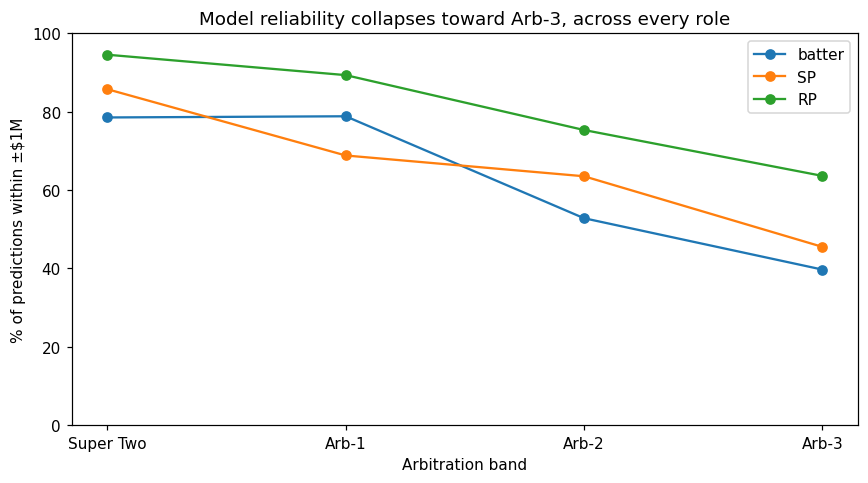

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
band_order = ["Super Two", "Arb-1", "Arb-2", "Arb-3"]
for role in ("batter", "SP", "RP"):
    sub = band_table[band_table["role"] == role].set_index("band").reindex(band_order)
    ax.plot(band_order, sub["within_$1M_pct"], marker="o", label=role)
ax.set_ylabel("% of predictions within \u00b1$1M")
ax.set_xlabel("Arbitration band")
ax.set_title("Model reliability collapses toward Arb-3, across every role")
ax.legend()
ax.set_ylim(0, 100)
fig.tight_layout()


## Conclusions

- **Two real data-quality issues were found and removed**: multi-year extensions mislabeled as
  one-year arb contracts, and a handful of broken stats-join rows (root cause: player-ID collisions,
  separately under repair).
- **A bigger, previously-invisible bug was found and fixed**: `position` doesn't reliably separate
  starters from relievers (Corbin Burnes and 100+ others were mislabeled). Reclassifying by actual
  workload (`games_started_3y / games_3y`) fixed real corruption in both the SP and RP training pools.
- **The model's errors are not random noise** — they're a structured functional-form problem: an
  additive WAR+service_time formula over-credits high-WAR arb-1 players (a real bucket ceiling exists)
  and badly under-credits elite players approaching free agency (real walk-year market pull). A
  `WAR × service_time` interaction term plus a `log(AAV)` target address most of this.
- **Shohei Ohtani is a genuine, irreducible outlier** (a two-way player with no real comparable) —
  excluded rather than chased with more model complexity.
- **Reliability varies sharply by arbitration band, not just by role.** Super Two and Arb-1 are
  trustworthy point estimates (~79-95% of predictions within ±$1M). Arb-2 is noticeably weaker.
  **Arb-3 should be treated as a floor/starting point, not a final number** — as low as 40% within
  ±$1M for batters, and RP-Arb-3 specifically has near-zero R² despite a decent hit-rate, meaning
  the model barely explains relative differences among elite walk-year relievers even though its
  absolute misses aren't catastrophic.

**Open item:** the player-ID collision fix (Section 2, Issue 2) is blocked on a live FanGraphs 403 from
this environment — `dataset/players.csv` is already corrected, but stats haven't been re-fetched and
rejoined yet. Rerunning this notebook after that lands would be worth doing, though the affected rows
are already excluded here so no result above should change materially.
